<a href="https://colab.research.google.com/github/alejandrocaro90-sudo/gdp-dashboard/blob/main/notebook/udacity_cs344_hw1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Laboratorio Carlos, Cristian, Samuel y Alejandro caro

Tarea 1 HW1

In [ ]:
# Homework 1 for Udacity CS344 Course, Intro to Parallel Programming
# clone the code repo,
!rm -rf udacity-cs344-colab
!git clone https://github.com/depctg/udacity-cs344-colab
!pip install git+https://github.com/depctg/nvcc4jupyter.git

# Install OpenCV development files
!apt-get update
!apt-get install -y libopencv-dev

# load cuda plugin
%config NVCCPluginV2.static_dir = True
%config NVCCPluginV2.relative_dir = "udacity-cs344-colab/src/HW1"
%load_ext nvcc_plugin

# change to work directory, generate makefiles
!mkdir -p udacity-cs344-colab/build
%cd udacity-cs344-colab/build
!cmake -DCMAKE_CUDA_ARCHITECTURES=native ../src

Cloning into 'udacity-cs344-colab'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 144 (delta 14), reused 12 (delta 12), pack-reused 120 (from 1)
Receiving objects: 100% (144/144), 3.93 MiB | 8.52 MiB/s, done.
Resolving deltas: 100% (43/43), done.
  Cloning https://github.com/depctg/nvcc4jupyter.git to /tmp/pip-req-build-c764ciez
  Running command git clone --filter=blob:none --quiet https://github.com/depctg/nvcc4jupyter.git /tmp/pip-req-build-c764ciez
  Resolved https://github.com/depctg/nvcc4jupyter.git to commit 63b811d987446c2a3783845b7b85cda6e562b71a
  Preparing metadata (setup.py) ... done
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5

In [ ]:
%%cuda --name student_func.cu

// Homework 1
// Color to Greyscale Conversion

//A common way to represent color images is known as RGBA - the color
//is specified by how much Red, Grean and Blue is in it.
//The 'A' stands for Alpha and is used for transparency, it will be
//ignored in this homework.

//Each channel Red, Blue, Green and Alpha is represented by one byte.
//Since we are using one byte for each color there are 256 different
//possible values for each color.  This means we use 4 bytes per pixel.

//Greyscale images are represented by a single intensity value per pixel
//which is one byte in size.

//To convert an image from color to grayscale one simple method is to
//set the intensity to the average of the RGB channels.  But we will
//use a more sophisticated method that takes into account how the eye
//perceives color and weights the channels unequally.

//The eye responds most strongly to green followed by red and then blue.
//The NTSC (National Television System Committee) recommends the following
//formula for color to greyscale conversion:

//I = .299f * R + .587f * G + .114f * B

//Notice the trailing f's on the numbers which indicate that they are
//single precision floating point constants and not double precision
//constants.

//You should fill in the kernel as well as set the block and grid sizes
//so that the entire image is processed.

#include "utils.h"

__global__
void rgba_to_greyscale(const uchar4* const rgbaImage,
                       unsigned char* const greyImage,
                       int numRows, int numCols)
{
  //First create a mapping from the 2D block and grid locations
  //to an absolute 2D location in the image, then use that to
  //calculate a 1D offset

  int x = blockIdx.x * blockDim.x + threadIdx.x;
  int y = blockIdx.y * blockDim.y + threadIdx.y;

  if (x < numCols && y < numRows) {
    int idx = y * numCols + x;
    uchar4 rgba = rgbaImage[idx];
    greyImage[idx] = (unsigned char)(.299f * rgba.x + .587f * rgba.y + .114f * rgba.z);
  }
}

void your_rgba_to_greyscale(const uchar4 * const h_rgbaImage, uchar4 * const d_rgbaImage,
                            unsigned char* const d_greyImage, size_t numRows, size_t numCols)
{
  //This function is typically used when calling from C++ host code.
  //For PyCUDA, the kernel launch will be directly managed by Python.
  //The blockSize and gridSize will be determined and passed from the Python side.

  // Example of kernel launch (commented out for PyCUDA usage):
  // const dim3 blockSize(16, 16, 1);
  // const dim3 gridSize( (numCols + blockSize.x - 1) / blockSize.x, (numRows + blockSize.y - 1) / blockSize.y, 1);
  // rgba_to_greyscale<<<gridSize, blockSize>>>(d_rgbaImage, d_greyImage, numRows, numCols);

  // cudaDeviceSynchronize(); checkCudaErrors(cudaGetLastError());
}

'File written in /content/udacity-cs344-colab/src/HW1/student_func.cu'

In [ ]:
# make the cuda project
!make HW1
print("\n====== RESULT OF HW1 =======\n")
!bin/HW1 ../src/HW1/cinque_terre.gold

[ 20%] Building NVCC (Device) object HW1/CMakeFiles/HW1.dir/HW1_generated_student_func.cu.o
nvcc fatal   : Unsupported gpu architecture 'compute_30'
CMake Error at HW1_generated_student_func.cu.o.cmake:223 (message):
  Error generating
  /content/udacity-cs344-colab/build/udacity-cs344-colab/build/udacity-cs344-colab/build/udacity-cs344-colab/build/HW1/CMakeFiles/HW1.dir//./HW1_generated_student_func.cu.o


make[3]: *** [HW1/CMakeFiles/HW1.dir/build.make:77: HW1/CMakeFiles/HW1.dir/HW1_generated_student_func.cu.o] Error 1
make[2]: *** [CMakeFiles/Makefile2:220: HW1/CMakeFiles/HW1.dir/all] Error 2
make[1]: *** [CMakeFiles/Makefile2:228: HW1/CMakeFiles/HW1.dir/rule] Error 2
make: *** [Makefile:124: HW1] Error 2

====== RESULT OF HW1 =======

/bin/bash: line 1: bin/HW1: No such file or directory


FileNotFoundError: [Errno 2] No such file or directory: 'HW1_output.png'

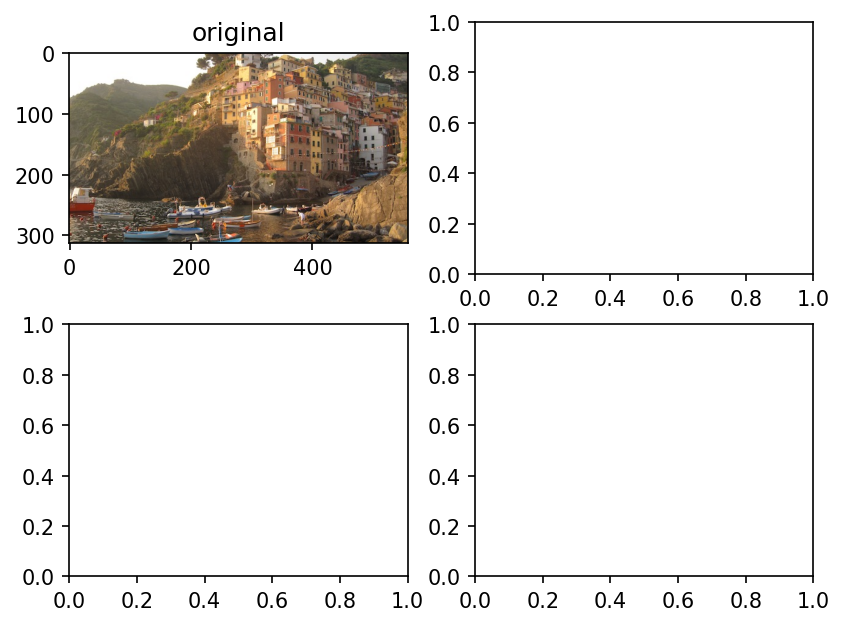

In [ ]:
# plot output images
import matplotlib.pyplot as plt
_,ax = plt.subplots(2,2, dpi=150)

ax[0][0].imshow(plt.imread("../src/HW1/cinque_terre_small.jpg"))
ax[0][0].set_title("original")
ax[0][0].grid(False)

ax[0][1].imshow(plt.imread("HW1_output.png"))
ax[0][1].set_title("output")
ax[0][1].grid(False)

ax[1][0].imshow(plt.imread("HW1_reference.png"))
ax[1][0].set_title("reference")
ax[1][0].grid(False)

ax[1][1].imshow(plt.imread("HW1_differenceImage.png"))
ax[1][1].set_title("difference")
ax[1][1].grid(False)

plt.show()

El código establece el entorno necesario para trabajar con CUDA y OpenCV, lo cual es esencial para tareas de programación paralela que involucren procesamiento de imágenes, como la conversión de imágenes a escala de grises.

La imagen no es RGBA, asegurémonos de que está en el formato correcto


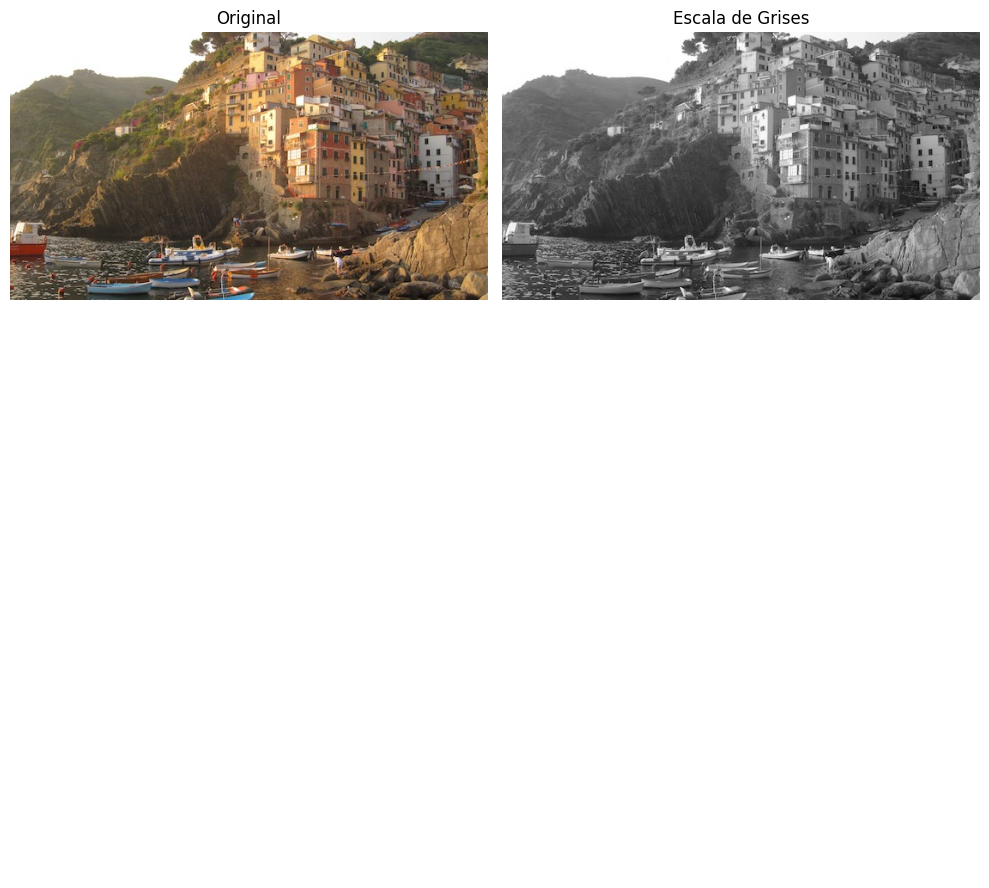

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('../src/HW1/cinque_terre_small.jpg', cv2.IMREAD_UNCHANGED)


if image.shape[2] == 4:
    print("La imagen es RGBA")
else:
    print("La imagen no es RGBA")


gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Crear los subgráficos
fig, axs = plt.subplots(2, 2, figsize=(10, 10))


axs[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Convertir de BGR a RGB para Matplotlib
axs[0, 0].set_title('Original')
axs[0, 0].axis('off')


axs[0, 1].imshow(gray_image, cmap='gray')
axs[0, 1].set_title('Escala de Grises')
axs[0, 1].axis('off')


axs[1, 0].axis('off')
axs[1, 1].axis('off')

# Mostrar la figura
plt.tight_layout()
plt.show()

In [ ]:
pip install pycuda opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 46.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 13.8 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=2e33efe402839bd707c72907e6cba5960f41b860825b905910f4a7001f4a3fa2
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


El código establece el entorno necesario para trabajar con CUDA y OpenCV, lo cual es esencial para tareas de programación paralela que involucren procesamiento de imágenes, como la conversión de imágenes a escala de grises.